In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error,r2_score

In [3]:
df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\downloads\Boston.csv")

In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,CAT. MEDV,Unnamed: 15,Unnamed: 16
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,0,NaN,NaN
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,0,NaN,NaN
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,1,NaN,NaN
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1,NaN,NaN
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1,NaN,NaN


In [5]:
df.columns.tolist()

['CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'MEDV',
 'CAT. MEDV',
 'Unnamed: 15',
 'Unnamed: 16']

In [7]:
df.drop(columns=['Unnamed: 15',
 'Unnamed: 16','CAT. MEDV'],inplace=True, errors="ignore")

In [8]:
X=df[['RM', 'LSTAT','PTRATIO']]
y=df['MEDV']

In [9]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [11]:
#scaling
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [12]:
model=Sequential([Dense(128,activation='relu',input_shape=(3,)),Dense(64,activation='relu'),Dense(1)])

C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
model.fit(x_train,y_train,epochs=100,verbose=0)

In [15]:
print("accuracy:",model.evaluate(x_test,y_test))
pred=model.predict(x_test[:5])
print("predicted:",pred)
print("actual:",y_test[:5].values)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 23.2331 - mae: 3.3250  
accuracy: [23.233121871948242, 3.325010061264038]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
predicted: [[26.176226]
 [30.488583]
 [25.62942 ]
 [29.238886]
 [17.163336]]
actual: [28.4 31.1 23.5 26.6 19.6]


In [1]:
# Import
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load data
df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\downloads\HousingData.csv")

# Clean dataset
df.drop(columns=['Unnamed: 15','Unnamed: 16','CAT. MEDV'], inplace=True, errors='ignore')

# Select best features
X = df[['LSTAT','PTRATIO','RM']]
y = df['MEDV']

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

# Scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Model (DNN for linear regression)
model = Sequential([
    Dense(128, activation='relu', input_shape=(3,)),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
model.fit(x_train, y_train, epochs=100, validation_split=0.05, verbose=0)

# Evaluate
loss, mae = model.evaluate(x_test, y_test)
print("MSE:", loss)
print("MAE:", mae)

# Predict
y_pred = model.predict(x_test)

# Show predictions vs actual
for p, a in zip(y_pred[:10], y_test[:10]):
    print(f"Predicted: {p[0]:.2f} | Actual: {a}")

C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 105.7051 - mae: 7.1235 
MSE: 105.705078125
MAE: 7.123528957366943
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Predicted: 21.87 | Actual: 28.4
Predicted: 21.87 | Actual: 31.1
Predicted: 21.87 | Actual: 23.5
Predicted: 21.87 | Actual: 26.6
Predicted: 21.87 | Actual: 19.6
Predicted: 21.87 | Actual: 14.3
Predicted: 21.87 | Actual: 50.0
Predicted: 21.87 | Actual: 14.3
Predicted: 21.87 | Actual: 20.7
Predicted: 21.87 | Actual: 37.6


C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 19.2760 - mae: 2.7773
MSE: [19.275968551635742, 2.7772841453552246]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predictions: [[ 8.830068]
 [18.077192]
 [21.436094]
 [31.156376]
 [25.30924 ]]
Actual: [ 7.2 18.8 19.  27.  22.2]


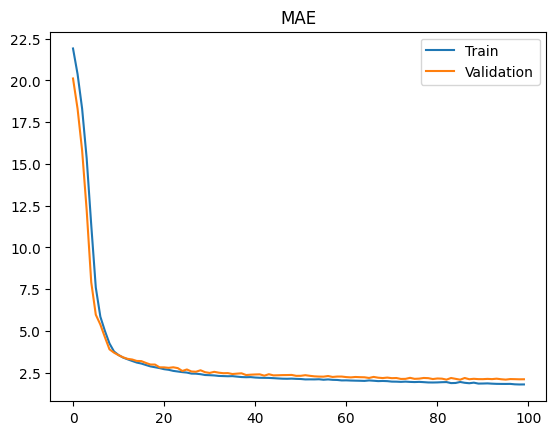

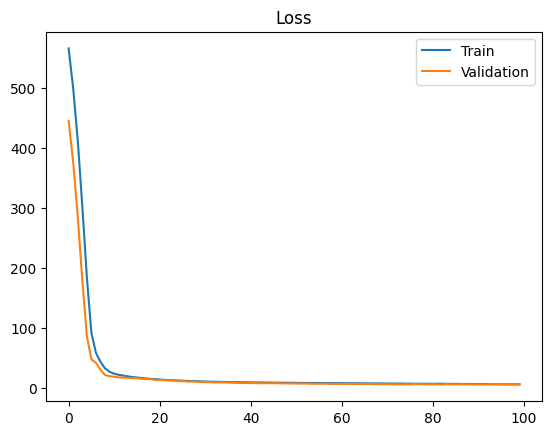

In [7]:
from tensorflow.keras.datasets import boston_housing
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

# Load dataset
(x_train, y_train), (x_test, y_test) = boston_housing.load_data()

# Scale data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(13,)),
    Dense(64, activation='relu'),
    Dense(1)
])

# Compile
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Train
history = model.fit(x_train, y_train, epochs=100, verbose=0,validation_split=0.1)

# Evaluate
print("MSE:", model.evaluate(x_test, y_test))

# Prediction
pred = model.predict(x_test[:5])

print("Predictions:", pred)
print("Actual:", y_test[:5])

import matplotlib.pyplot as plt

# MAE graph
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('MAE')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [3]:
# Evaluate
print("MSE:", model.evaluate(x_test, y_test))

# Prediction
pred = model.predict(x_test[:5])

print("Predictions:", pred)
print("Actual:", y_test[:5])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 17.8465 - mae: 2.6792
MSE: [17.846454620361328, 2.6792266368865967]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predictions: [[ 8.567739]
 [18.566795]
 [21.73308 ]
 [34.351418]
 [25.360476]]
Actual: [ 7.2 18.8 19.  27.  22.2]
